<a href="https://colab.research.google.com/github/mostafaelhussien/hands-on-machine-learning/blob/main/Logistic_Regression_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn import preprocessing




In [ ]:
# #### Slide 3/51: Loading packages  ####

# import os
# import warnings
# warnings.filterwarnings("ignore", category=FutureWarning)
# # Helper packages.
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path
# # Scikit-learn package for logistic regression.
# from sklearn import linear_model
# # Model set up and tuning packages from scikit-learn.
# from sklearn.model_selection import train_test_split
# from sklearn.model_selection import GridSearchCV
# # Scikit-learn packages for evaluating model performance.
# from sklearn import metrics
# # Scikit-learn package for data preprocessing.
# from sklearn import preprocessing



In [ ]:
import os
import pandas as pd
os.listdir()
from google.colab import drive
drive.mount('/content/drive')
os.listdir('/content/drive/MyDrive/ML Data')
data_dir = '/content/drive/MyDrive/ML Data'
df=pd.read_csv(data_dir + '/healthcare-dataset-stroke-data.csv')
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
#### Slide 4/51: Directory settings  ####

# Set 'main_dir' to location of the project folder
home_dir=Path(".").resolve()
main_dir=home_dir.parent
print(main_dir)
data_dir=str(main_dir)+"/data"
print(data_dir)

/
//data


In [ ]:
#Subset Data
df_subset=df[["bmi","age","avg_glucose_level","heart_disease","ever_married","Residence_type","hypertension","smoking_status","gender","work_type","stroke","id"]]
print(df_subset.shape)
df_subset.head()

(5110, 12)


,bmi,age,avg_glucose_level,heart_disease,ever_married,Residence_type,hypertension,smoking_status,gender,work_type,stroke,id
0,36.6,67.0,228.69,1,Yes,Urban,0,formerly smoked,Male,Private,1,9046
1,NaN,61.0,202.21,0,Yes,Rural,0,never smoked,Female,Self-employed,1,51676
2,32.5,80.0,105.92,1,Yes,Rural,0,never smoked,Male,Private,1,31112
3,34.4,49.0,171.23,0,Yes,Urban,0,smokes,Female,Private,1,60182
4,24.0,79.0,174.12,0,Yes,Rural,1,never smoked,Female,Self-employed,1,1665


In [ ]:
#### Slide 13/51: Data prep: target variable  ####

# 1-Make sure the target is labeled

print(df_subset["stroke"].dtypes) #bool
unique_values=sorted(df_subset["stroke"].unique())
print(unique_values)
df_subset["stroke"]=np.where(df_subset["stroke"]==unique_values[0],False,True)
print(df_subset["stroke"].dtypes) #bool

#Target is labeled (false or true)

bool
[np.False_, np.True_]
bool


In [ ]:
#Data preprocessing,

# 2-Check for NA

print(df_subset.isnull().sum()) #bmi 201 na,smoking status 1544 na
print(len(df_subset)) #5110
percent_missing=df_subset.isnull().sum()*100/len(df_subset)
print(percent_missing)
#
# - هنا إحنا بنقسم:
#   - عدد القيم الناقصة
#   - على عدد الصفوف الكلي
# - النتيجة **كسر عشري أقل من أو يساوي 1 دائمًا**.

# مثال:
# - 200 ÷ 5110 ≈ 0.039
#
# * 100
# شرح السطر:
# - الضرب في 100 **لا يزيد القيمة الخام**،
# - لكنه بيحوّل الكسر العشري إلى **نسبة مئوية**.

# مثال:
# - 0.039 × 100 = 3.9%

#We will delete the columns which contain either 50% or more than 50% missing data from the subset (none already)
percentage=50.0
#
#السطر ده بيحدد **النسبة القصوى المسموح بها للقيم الناقصة** في أي عمود.
min_count=int(((100-percentage)/100)*df_subset.shape[0]+1) #df_subset.shape[0] عدد الصفوف..df_subset.shape[1] عدد الأعمدة
#السطر ده بيخزن **أقل عدد مقبول من القيم غير الناقصة** في أي عمود.

# #دي خطوة احترازية بسيطة علشان:
# - ما نمسكش حالة حدّية بالظبط
# - نضمن إن العمود يكون **أكتر من 50٪ مش ناقص**
# مش 50٪ بالظبط.
df_subset=df_subset.dropna(axis=1,thresh=min_count)
print(df_subset.shape) #5110 rows *12 columns
print(df_subset.isnull().sum()) #no change as no column has more than 50$ NA


bmi                   201
age                     0
avg_glucose_level       0
heart_disease           0
ever_married            0
Residence_type          0
hypertension            0
smoking_status       1544
gender                  0
work_type               0
stroke                  0
id                      0
dtype: int64
5110
bmi                   3.933464
age                   0.000000
avg_glucose_level     0.000000
heart_disease         0.000000
ever_married          0.000000
Residence_type        0.000000
hypertension          0.000000
smoking_status       30.215264
gender                0.000000
work_type             0.000000
stroke                0.000000
id                    0.000000
dtype: float64
(5110, 12)
bmi                   201
age                     0
avg_glucose_level       0
heart_disease           0
ever_married            0
Residence_type          0
hypertension            0
smoking_status       1544
gender                  0
work_type               0
stroke      

In [ ]:
def fillna(df):
  #fill numerics with mean Step 3A
  numeric_columns=df.select_dtypes(include=['int64',"float64"]).columns
  df[numeric_columns]= df[numeric_columns].fillna( df[numeric_columns].mean())
  #fill categorcial with mode Step 3B
  categorical_columns=df.select_dtypes(include=["object"]).columns
  df[categorical_columns]=df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])
  return df

df_subset=fillna(df_subset)
print(df_subset.isnull().sum()) #no more NA

bmi                  0
age                  0
avg_glucose_level    0
heart_disease        0
ever_married         0
Residence_type       0
hypertension         0
smoking_status       0
gender               0
work_type            0
stroke               0
id                   0
dtype: int64


In [ ]:
#Continue Preprocessing-----Split Data


#We’ll now split the data subset into a dataframe consisting of features and an target variable array

columns_to_drop_from_X=["stroke"]+["id"]
X=df_subset.drop(columns_to_drop_from_X,axis=1)
y=np.array(df_subset["stroke"])
print(X.dtypes)
# Convert Categorical ( object+int64)
X=pd.get_dummies(X,columns=["gender","ever_married","work_type","Residence_type","smoking_status","heart_disease","hypertension"],dtype=float,drop_first=True)
print(X.dtypes)


bmi                  float64
age                  float64
avg_glucose_level    float64
heart_disease          int64
ever_married          object
Residence_type        object
hypertension           int64
smoking_status        object
gender                object
work_type             object
dtype: object
bmi                            float64
age                            float64
avg_glucose_level              float64
gender_Male                    float64
gender_Other                   float64
ever_married_Yes               float64
work_type_Never_worked         float64
work_type_Private              float64
work_type_Self-employed        float64
work_type_children             float64
Residence_type_Urban           float64
smoking_status_never smoked    float64
smoking_status_smokes          float64
heart_disease_1                float64
hypertension_1                 float64
dtype: object


In [ ]:
# We’ll run logistic regression initially on the training data
# Now,we will split into training data and test data
#Preprocessing Step 4

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1)

In [ ]:
#Preprocessing Step 5 :Feature Scaling

# We will use sklearn’s MinMaxScaler for feature scaling in this module

# Initialize Scaler
from sklearn import preprocessing
scaler=preprocessing.MinMaxScaler()
#Fit on Training Data

# Ensure X and y are defined from previous cells, and then split the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1)

scaler.fit(X_train)

#Scale on Training and Test data
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
# Set up Logistic Regression Model

logistic_regression_model=linear_model.LogisticRegression()
print(logistic_regression_model.penalty,logistic_regression_model.C) #penalty l2,C=1.0.We will discuss what that means later in more detail when we tune our model


l2 1.0


In [ ]:
# Fit the Model

logistic_regression_model.fit(X_train_scaled,y_train)

#predict on Test Data

predicted_values=logistic_regression_model.predict(X_test_scaled)
print(predicted_values[:20])

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True]


In [ ]:
#scikit-learn: metrics package
# We will use the following methods from this library:

# confusion_matrix
# accuracy_score
# classification_report
# roc_curve
# auc
from sklearn import metrics
# Both confusion_matrix and accuracy_score take two arguments:

# Original data labels
# Predicted labels

# Take a look at test data confusion matrix.
conf_matrix_test=metrics.confusion_matrix(y_test,predicted_values)
print(conf_matrix_test) #1450 TN,0 FP,83 FN,0 TP----Never said has a stroke
acc_score=metrics.accuracy_score(y_test,predicted_values)
target_names=["No Stroke","Stroke"]
class_report=metrics.classification_report(
    y_test,
    predicted_values,
    target_names=target_names,

)
print(acc_score)
print(class_report)


[[   0   83]
 [   0 1450]]
0.9458577951728636
              precision    recall  f1-score   support

   No Stroke       0.00      0.00      0.00        83
      Stroke       0.95      1.00      0.97      1450

    accuracy                           0.95      1533
   macro avg       0.47      0.50      0.49      1533
weighted avg       0.89      0.95      0.92      1533



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Save Accuracy Score

# acc_score=metrics.accuracy_score(y_test,predicted_values)
# target_names=["No Stroke","Stroke"]
# class_report=metrics.classification_report(
#     y_test,
#     predicted_values,
#     target_names=target_names

model_final={
    "metrics" :"accuracy",
    "values" : round(acc_score,4),
    "model"  : "logistic"
}
print(model_final)

{'metrics': 'accuracy', 'values': 0.9459, 'model': 'logistic'}


In [ ]:
# Getting probabilities instead of class labels

# Now we can start gathering the various components to build our ROC curve and calculate the AUC

# Again, we are looking to ensure that our model has better predictive ability than making a random guess

# The ROC curve is a performance metric used to compare classification models to measure predictive accuracy

# The AUC (Area under the ROC Curve) should be above 0.5 to say the model is better than a random guess
#TPR=TP/(TP+FN)
#TNR=TN/(TN+FP)

#Get Probabilities instead of predicted values predicted_values=logistic_regression_model.predict(X_test_scaled)
probabilities=logistic_regression_model.predict_proba(X_test_scaled) #where:X_test_scaled=scaler.transform(X_test)
print(probabilities[0:5,:]) #[prob of no stroke (0),prob of stroke (1)] for first 5 rows
#
# Extract ONLY the probability of class 1 (usually the “positive” class, e.g., Stroke=1).:
probabilities_of_stroke=probabilities[:,1]
print(probabilities_of_stroke[0:5]) #Probabilities of Stroke for first 5 Rows

#Computing TPR,FPR,and threshold
tpr,fpr,threshold=metrics.roc_curve(y_test,probabilities_of_stroke) #Y_test:Actual Test Data
print("False Positive",fpr[:5]) #First 5 Rows FPR
print("True Positive",tpr[:5]) #First 5 Rows TPR
print("Threshold",threshold[:5]) #Apply threshold to all samples,calculate TPR and FPR,changing threshold then recalculate TPR and FPR
# ✅ Threshold is NOT changing per row
# ✅ Threshold changes per ROC point
# ✅ Each threshold is applied to ALL rows
# ✅ Each (FPR[i], TPR[i]) corresponds to threshold[i]


[[0.01690786 0.98309214]
 [0.17459487 0.82540513]
 [0.01105454 0.98894546]
 [0.16413964 0.83586036]
 [0.03501468 0.96498532]]
[0.98309214 0.82540513 0.98894546 0.83586036 0.96498532]
False Positive [0.         0.00068966 0.41034483 0.41034483 0.45586207]
True Positive [0.         0.         0.         0.01204819 0.01204819]
Threshold [       inf 0.99811236 0.98497007 0.98496993 0.9825562 ]


In [ ]:
#Computing TPR,FPR,and threshold
tpr,fpr,threshold=metrics.roc_curve(y_test,probabilities_of_stroke) #Y_test:Actual Test Data
print("False Positive",fpr[:5]) #First 5 Rows FPR
print("True Positive",tpr[:5]) #First 5 Rows TPR
print("Threshold",threshold[:5]) #Apply threshold to all samples,calculate TPR and FPR,changing threshold then recalculate TPR and FPR
# ✅ Threshold is NOT changing per row
# ✅ Threshold changes per ROC point
# ✅ Each threshold is applied to ALL rows
# ✅ Each (FPR[i], TPR[i]) corresponds to threshold[i]

False Positive [0.         0.00068966 0.41034483 0.41034483 0.45586207]
True Positive [0.         0.         0.         0.01204819 0.01204819]
Threshold [       inf 0.99811236 0.98497007 0.98496993 0.9825562 ]


In [ ]:
#Calculating Area Under Curve AUC

#Get AUC from FPR,TPR
auc=metrics.auc(fpr,tpr)
print(auc)
#قيمة الـ AUC معناها:

# قد إيه الموديل شاطر إنه يدي Score أعلى لمريض Stroke أكتر من شخص سليم

# 📌 AUC = 0.145
# ➡️ ده سيء جدًا
# ➡️ الموديل غالبًا بيرتّب الحالات بالعكس
# يعني غالبًا:

# الأشخاص السليمين بياخدوا Probability أعلى من مرضى الـ Stroke 😬

0.1452928957208143


[[0.01690786 0.98309214]
 [0.17459487 0.82540513]
 [0.01105454 0.98894546]
 [0.16413964 0.83586036]
 [0.03501468 0.96498532]]
[0.98309214 0.82540513 0.98894546 0.83586036 0.96498532]
0.8547071042791856


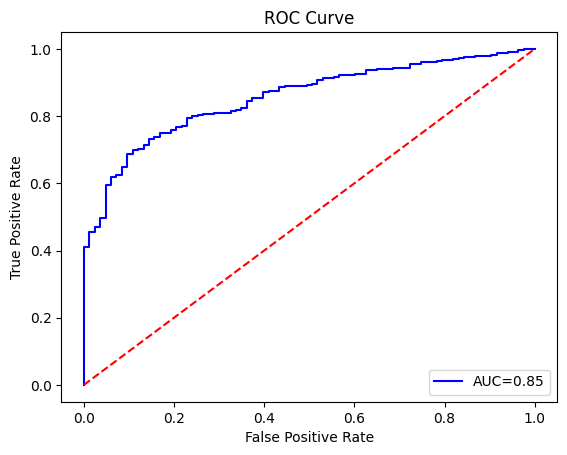

[False  True]


In [ ]:
# Plot ROC
#Firstly Remember:
# #Get Probabilities instead of predicted values predicted_values=logistic_regression_model.predict(X_test_scaled)
# probabilities=logistic_regression_model.predict_proba(X_test_scaled) #where:X_test_scaled=scaler.transform(X_test)
# print(probabilities[0:5,:]) #[prob of no stroke (0),prob of stroke (1)] for first 5 rows
# #
# # Extract ONLY the probability of class 1 (usually the “positive” class, e.g., Stroke=1).:
# probabilities_of_stroke=probabilities[:,1]
# print(probabilities_of_stroke[0:5]) #Probabilities of Stroke for first 5 Rows

# #Computing TPR,FPR,and threshold
# tpr,fpr,threshold=metrics.roc_curve(y_test,probabilities_of_stroke) #Y_test:Actual Test Data
# print("False Positive",fpr[:5]) #First 5 Rows FPR
# print("True Positive",tpr[:5]) #First 5 Rows TPR
# print("Threshold",threshold[:5]) #Apply threshold to all samples,calculate TPR and FPR,changing threshold then recalculate TPR and FPR

#Then:
probabilities=logistic_regression_model.predict_proba(X_test_scaled)
print(probabilities[0:5,:])
probabilities_of_stroke=probabilities[:,1]
print(probabilities_of_stroke[0:5])
fpr,tpr,threshold=metrics.roc_curve(y_test,probabilities_of_stroke) #Y_test:Actual Test Data #Take Care of Arrangement fpr,tpr,threshold
auc=metrics.auc(fpr,tpr)
print(auc)

#Then Visualize:
plt.plot(fpr,tpr,"blue",label=f"AUC={auc:.2f}") #%.2f: بتقرّب الرقم ويعرضه برقمين بعد العلامة العشرية..النتيجة منحنى أزرق تحت الخط الأحمر..هو ده ال ROC كيرف
plt.plot([0,1],[0,1],"r--") #ٍخط أحمر مستقيم داش -- مجرد موديل عشوائي للمقارنة
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
#AUC المساحة اللي تحت الكيرف الأزرق
print(logistic_regression_model.classes_)


In [ ]:
#Accuracy was calculated previously on test Data
predicted_values=logistic_regression_model.predict(X_test_scaled)

acc_score = metrics.accuracy_score(y_test,predicted_values)
print(acc_score) #.9458


# Now,we weill check Accuracy on Training Data

trained_acc_score=logistic_regression_model.score(X_train_scaled,y_train)
#X_train_scaled=scaler.transform(X_train)
print("Accuracy on Training Data", trained_acc_score) #.9535,Model is not so badly overfitted

0.9458577951728636
Accuracy on Training Data 0.9535923958624546


In [ ]:
#A-Prepare the Parameter Grid l1,l2 and C (Regularization Constant)

penalty=["l1","l2"]
C=np.logspace(0,10,10) #Creates a 10 Nr Array from 10 power zero to 10 power 10
print("Regularization Constant",C)
hyperparameters=dict(C= C,penalty=penalty) #Create Hyperparameters Options Dictionary
print(hyperparameters) #l1,l2,and C are hyperparameters  chosen by you before training.

#Model parameters are the values the model learns automatically from data during training.
# Examples:

# Logistic Regression weights b1,b2,…,bnb_1, b_2, \dots, b_nb1​,b2​,…,bn​
# Bias/intercept b0b_0b0​

#B- Setup and Run GridSearchCV
# clf=CrossValidation Logistic Function
#liblinear
# Good for small/medium datasets and binary classification (or one-vs-rest).
# Supports L1 and L2 penalties.
# If you want L1 (Lasso), liblinear is a common choice.

clf=GridSearchCV(
    linear_model.LogisticRegression(solver="liblinear"),
    hyperparameters, #Grid Parameters l1,l2 and C--10 C Values,2 Penalty Types--20 Combinations
    cv=10, #10 folds for CV--20 Combinations and 10 CV fold=200 Training Model Total
    verbose=0  #No Messages to Show during running Code
)

#Fit GridSearchCV

best_model=clf.fit(X_train_scaled,y_train) #We give the learn command to scaled training features X_train_scaled and correct answers y_train
#It tries 200 Training Trials (20 Combinations *10 CV Fold)
print(best_model)

#C-Check which Parameters won:

#Get best penalty and constant parameters

penalty=best_model.best_estimator_.get_params()["penalty"]
C=best_model.best_estimator_.get_params()["C"]
print("Best Penalty",penalty)
print("Best C",C)
#Best Penalty l2
#Best C 1.0

#D-Predict on Test Data with best model
# X_test_scaled = scaler.transform(X_test)
best_predicted_values=best_model.predict(X_test_scaled)
print(best_predicted_values)
best_accuracy_score=metrics.accuracy_score(y_test,best_predicted_values)
print("best_accuracy_score (using best predicted values)",best_accuracy_score) #.9485
trained_acc_score=best_model.score(X_train_scaled,y_train)
print("Accuracy on Training Data", trained_acc_score) #.9535

#Confusion Matrix and Classification Report for best model
best_confusion_matrix=metrics.confusion_matrix(y_test,best_predicted_values)
print(best_confusion_matrix)
target_names=["No Stroke","Stroke"]
best_classification_report=metrics.classification_report(
    y_test,
    best_predicted_values,
    target_names=target_names
)
print(best_classification_report)

#New Report:

# precision    recall  f1-score   support

#    No Stroke       0.00      0.00      0.00        83
#       Stroke       0.95      1.00      0.97      1450

#     accuracy                           0.95      1533
#    macro avg       0.47      0.50      0.49      1533
# weighted avg       0.89      0.95      0.92      1533

#Old Report:

#   precision    recall  f1-score   support

#    No Stroke       0.00      0.00      0.00        83
#       Stroke       0.95      1.00      0.97      1450

#     accuracy                           0.95      1533
#    macro avg       0.47      0.50      0.49      1533
# weighted avg       0.89      0.95      0.92      1533



Regularization Constant [1.00000000e+00 1.29154967e+01 1.66810054e+02 2.15443469e+03
 2.78255940e+04 3.59381366e+05 4.64158883e+06 5.99484250e+07
 7.74263683e+08 1.00000000e+10]
{'C': array([1.00000000e+00, 1.29154967e+01, 1.66810054e+02, 2.15443469e+03,
       2.78255940e+04, 3.59381366e+05, 4.64158883e+06, 5.99484250e+07,
       7.74263683e+08, 1.00000000e+10]), 'penalty': ['l1', 'l2']}
GridSearchCV(cv=10, estimator=LogisticRegression(solver='liblinear'),
             param_grid={'C': array([1.00000000e+00, 1.29154967e+01, 1.66810054e+02, 2.15443469e+03,
       2.78255940e+04, 3.59381366e+05, 4.64158883e+06, 5.99484250e+07,
       7.74263683e+08, 1.00000000e+10]),
                         'penalty': ['l1', 'l2']})
Best Penalty l2
Best C 1.0
[ True  True  True ...  True  True  True]
best_accuracy_score (using best predicted values) 0.9458577951728636
Accuracy on Training Data 0.9535923958624546
[[   0   83]
 [   0 1450]]
              precision    recall  f1-score   support

   No Str

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#C-Check which Parameters won:

#Get best penalty and constant parameters

penalty=best_model.best_estimator_.get_params()["penalty"]
C=best_model.best_estimator_.get_params()["C"]
print("Best Penalty",penalty)
print("Best C",C)

Best Penalty l2
Best C 1.0


In [ ]:
#D-Predict on Test Data with best model
# X_test_scaled = scaler.transform(X_test)
best_predicted_values=best_model.predict(X_test_scaled)
print(best_predicted_values)

[ True  True  True ...  True  True  True]


In [ ]:
# Save Model Best Accuracy Score:
best_model_final={
    "metrics":"accuracy",
    "values":round(best_accuracy_score,4),
    "model":"logistic_tuned"
}
print(best_model_final)

{'metrics': 'accuracy', 'values': 0.9459, 'model': 'logistic_tuned'}


In [ ]:
# Comparing ROC Curve for Both Models:
#Remember:

#Firstly Remember:
# #Get Probabilities instead of predicted values predicted_values=logistic_regression_model.predict(X_test_scaled)
# probabilities=logistic_regression_model.predict_proba(X_test_scaled) #where:X_test_scaled=scaler.transform(X_test)
# print(probabilities[0:5,:]) #[prob of no stroke (0),prob of stroke (1)] for first 5 rows
# #
# # Extract ONLY the probability of class 1 (usually the “positive” class, e.g., Stroke=1).:
# probabilities_of_stroke=probabilities[:,1]
# print(probabilities_of_stroke[0:5]) #Probabilities of Stroke for first 5 Rows

# #Computing TPR,FPR,and threshold
# tpr,fpr,threshold=metrics.roc_curve(y_test,probabilities_of_stroke) #Y_test:Actual Test Data
# print("False Positive",fpr[:5]) #First 5 Rows FPR
# print("True Positive",tpr[:5]) #First 5 Rows TPR
# print("Threshold",threshold[:5]) #Apply threshold to all samples,calculate TPR and FPR,changing threshold then recalculate TPR and FPR

#Then:
# probabilities=logistic_regression_model.predict_proba(X_test_scaled)
# print(probabilities[0:5,:])
# probabilities_of_stroke=probabilities[:,1]
# print(probabilities_of_stroke[0:5])
# fpr,tpr,threshold=metrics.roc_curve(y_test,probabilities_of_stroke) #Y_test:Actual Test Data #Take Care of Arrangement fpr,tpr,threshold
# auc=metrics.auc(fpr,tpr)
# print(auc)
#best_model=clf.fit(X_train_scaled,y_train)
best_test_probabilities=best_model.predict_proba(X_test_scaled) #[prob of 0,prob of 1]
print(best_test_probabilities[0:5,:]) #show 1st 5 rows--each row has two columns [prob of 0,prob of 1]
best_test_probabilities_of_stroke=best_test_probabilities[:,1] #for all rows,get the column 1 for probs of 1 (True)
print(best_test_probabilities_of_stroke[0:5])

[[0.0270809  0.9729191 ]
 [0.1682309  0.8317691 ]
 [0.01439035 0.98560965]
 [0.15641501 0.84358499]
 [0.0376667  0.9623333 ]]
[0.9729191  0.8317691  0.98560965 0.84358499 0.9623333 ]


0.8517407561279602


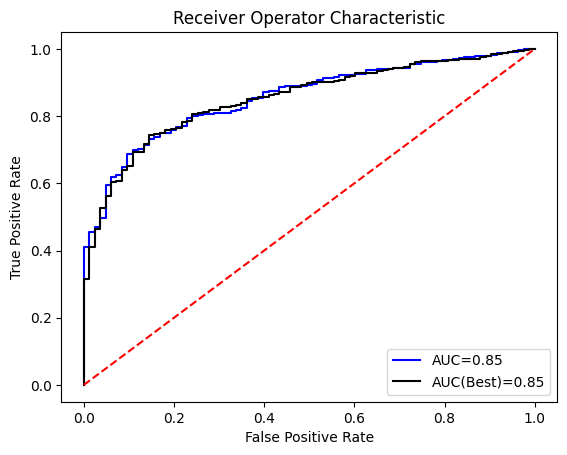

In [ ]:
# Get new ROC Curve with best AUC

best_fpr,best_tpr,best_threshold=metrics.roc_curve(y_test,best_test_probabilities_of_stroke)
best_auc=metrics.auc(best_fpr,best_tpr)
print(best_auc)

# Make ROC Curve Comparing both models
#Remember for the first Model:
# plt.plot(fpr,tpr,"blue",label=f"AUC={auc:.2f}") #%.2f: بتقرّب الرقم ويعرضه برقمين بعد العلامة العشرية..النتيجة منحنى أزرق تحت الخط الأحمر..هو ده ال ROC كيرف
# plt.plot([0,1],[0,1],"r--") #ٍخط أحمر مستقيم داش -- مجرد موديل عشوائي للمقارنة
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend(loc="lower right")
# plt.show()

plt.title("Receiver Operator Characteristic")
plt.plot(fpr,tpr,"blue",label=f"AUC={auc:.2f}") #Model 1
plt.plot(best_fpr,best_tpr,"black",label=f"AUC(Best)={best_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.plot([0,1],[0,1],"r--")
plt.show()